In [1]:
import pandas as pd
import numpy as np
import requests
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
import xgboost as xgb
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from datetime import datetime, timedelta
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")


In [2]:
import pyarrow.parquet as pq

table = pq.read_table(
    r"fhvhv_tripdata_2026-01.parquet"
)
df = table.to_pandas()
df.head()


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2026-01-01 00:50:37,2026-01-01 00:52:31,2026-01-01 00:54:30,2026-01-01 01:13:23,262,79,4.300,...,2.75,0.0,0.00,21.10,N,N,N,N,N,1.5
1,HV0003,B03404,B03404,2026-01-01 00:09:12,2026-01-01 00:12:17,2026-01-01 00:12:39,2026-01-01 00:22:42,195,52,1.890,...,0.00,0.0,0.00,9.10,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2026-01-01 00:16:16,2026-01-01 00:29:33,2026-01-01 00:31:34,2026-01-01 00:55:21,25,181,1.840,...,0.00,0.0,2.67,21.94,N,N,N,N,N,0.0
3,HV0005,B03406,None,2026-01-01 00:08:19,2026-01-01 00:09:08,2026-01-01 00:09:37,2026-01-01 00:22:12,141,226,3.307,...,2.75,0.0,0.00,13.42,N,N,N,N,Y,1.5
4,HV0005,B03406,None,2026-01-01 00:21:16,2026-01-01 00:26:30,2026-01-01 00:26:40,2026-01-01 00:39:06,226,226,2.060,...,0.00,0.0,2.98,11.39,N,N,N,N,Y,0.0


In [3]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
df['trip_duration_min'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60

In [4]:
df.columns

Index(['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num',
       'request_datetime', 'on_scene_datetime', 'pickup_datetime',
       'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles',
       'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax',
       'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay',
       'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag',
       'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee',
       'trip_duration_min'],
      dtype='object')

In [5]:
df_model = df.dropna()

In [6]:
cols = ['trip_miles', 'trip_time', 'base_passenger_fare']

(df_model[cols] == 0).sum()


trip_miles              2528
trip_time                737
base_passenger_fare    29765
dtype: int64

In [7]:
features = [
    'trip_miles',
    'trip_time',
    'PU_mean_fare',
    'DO_mean_fare',
    'hour',
    'day_of_week',
    'is_weekend'
]

pu_mean = df_model.groupby('PULocationID')['base_passenger_fare'].mean()
do_mean = df_model.groupby('DOLocationID')['base_passenger_fare'].mean()

df_model['PU_mean_fare'] = df_model['PULocationID'].map(pu_mean)
df_model['DO_mean_fare'] = df_model['DOLocationID'].map(do_mean)

df_model = df_model[
    (df_model['trip_miles'] > 0) &
    (df_model['trip_time'] > 0) &
    (df_model['base_passenger_fare'] > 0) & (df_model['PU_mean_fare']).notna() &
    (df_model['DO_mean_fare']).notna()]
df_model['hour'] = df_model['pickup_datetime'].dt.hour
df_model['day_of_week'] = df_model['pickup_datetime'].dt.dayofweek
df_model['is_weekend'] = df_model['day_of_week'].isin([5,6]).astype(int)



In [8]:
df_model_sample =df_model.sample(n=1_000_000, random_state=42)

In [9]:
X = df_model_sample[features]
y= df_model_sample['base_passenger_fare']
split_index = int(len(df_model_sample)*0.75)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]   

# Testing Regression Functions for Surge Price Estimation
### 1. Standard Linear Regression Model

### 2. Polynomial Regression Model

### 3. Log-Normal Regression Model

## Standard Linear Regression 
**Model**: 
$\beta_0$ + $\beta_1 * mi$  + $\beta_2 * t$ 

In [10]:
SLR_model = LinearRegression()
SLR_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
print("Intercept:", SLR_model.intercept_)
print("Miles coefficient:", SLR_model.coef_[0])
print("Time coefficient:", SLR_model.coef_[1])


Intercept: -10.279905595527381
Miles coefficient: 2.106106332268863
Time coefficient: 0.009582404510414108


In [12]:
from sklearn.metrics import r2_score
y_pred_linear = SLR_model.predict(X_test)
r2 = r2_score(y_test, y_pred_linear)
print("R²:", r2)


R²: 0.7852693541769451


### In the simple linear model, we see that approximately 77-80% the variance of y can be explained by variance in X. For a dynamic system, this makes sense.
- #### Approximately 77-80% of the data can be explained simply by trip miles and trip time as it relates to base passenger fare.
- #### This means that 20-23% of the data is unexplained variance, which can likely be accounted to noise such as holiday surges, demand surges, app traffic surges, etc. 

## Polynomial Regression
**Model**: 
$\beta_1 * mi$  + $\beta_2 * (mi)^2$ 

In [13]:
df_model_sample_poly =df_model.sample(n=500_000, random_state=42)

In [14]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [15]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression R²: {r2_poly:.3f}")


Polynomial Regression R²: 0.816


## Polynomial Regression has a very similar $R^2$ value
- ### As expected. The time and distance features, for polynomial and linear regression, have an approximately similar fit
- ### We should also expect log-linear to have roughly a similar value

## Log Linear Regression
**Model**: 
$log(Y)$ = $ {\displaystyle \beta_0 + \beta_1 * mi  + \beta_2 * t}$

In [16]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

y_log_train = np.log(y_train.clip(lower=0.01, upper=3000))
y_log_test  = np.log(y_test.clip(lower=0.01, upper=3000))

log_model = LinearRegression()
log_model.fit(X_train, y_log_train)

y_pred_log = log_model.predict(X_test)

y_pred_log_exp = np.exp(y_pred_log)
y_pred_log_exp= np.clip(y_pred_log_exp, a_min=None, a_max=3000)

In [17]:
r2_log = r2_score(y_log_test, y_pred_log)
print(f"R² in log space: {r2_log:.4f}")

R² in log space: 0.7350


## Log-Linear $R^2$ is also approximately 0.73
- ### Even with the addition of the pickup and dropoff fares, the $R^2$ relationship between trip distance/trip time and base passenger fare remains at 0.73
- ### We need to capture more non-linear effects in order to find an anomaly affecting the $R^2$ value 

In [18]:
import numpy as np

plot_sample_size = 3000 

plot_idx = np.random.choice(len(X_test), size=plot_sample_size, replace=False)

X_plot = X_test.iloc[plot_idx]
y_plot = y_test.iloc[plot_idx]

y_pred_linear_plot = y_pred_linear[plot_idx]
y_pred_poly_plot = y_pred_poly[plot_idx]
y_pred_log_plot = y_pred_log[plot_idx]


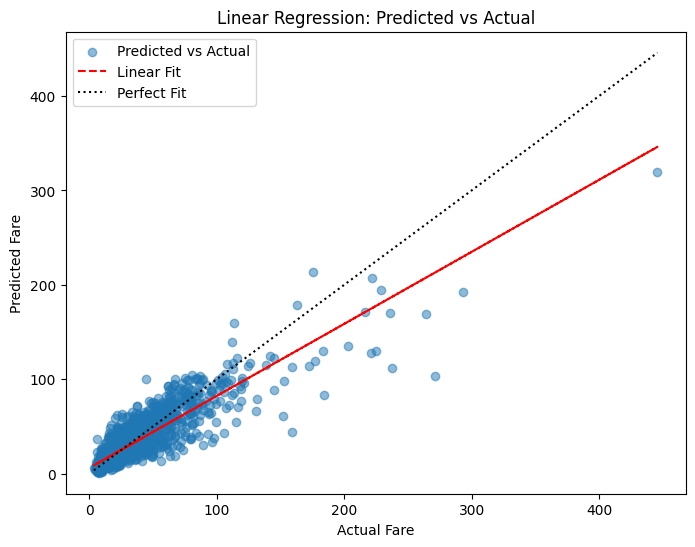

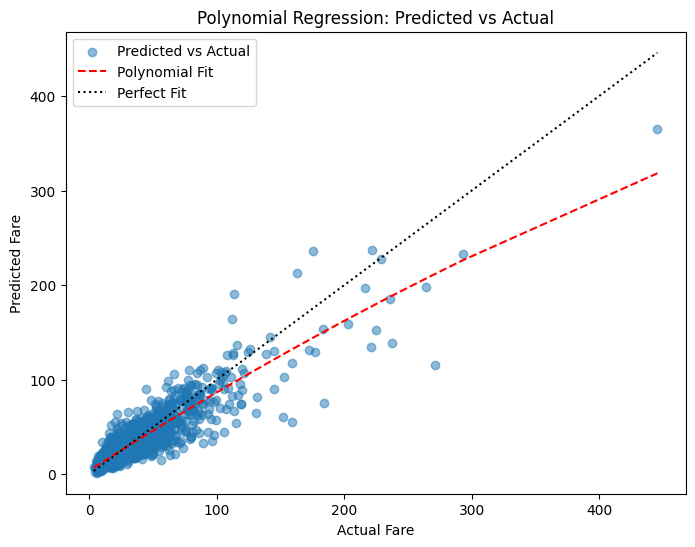

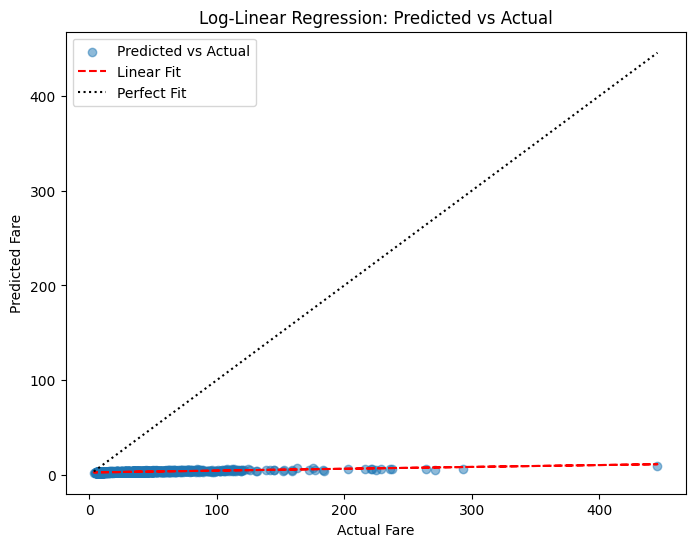

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_plot, y_pred_linear_plot, alpha=0.5, label="Predicted vs Actual")
z = np.polyfit(y_plot, y_pred_linear_plot, 1)  
p = np.poly1d(z)
plt.plot(y_plot, p(y_plot), "r--", label="Linear Fit")
plt.plot([y_plot.min(), y_plot.max()], [y_plot.min(), y_plot.max()], "k:", label="Perfect Fit")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_plot, y_pred_poly_plot, alpha=0.5, label="Predicted vs Actual")
z = np.polyfit(y_plot, y_pred_poly_plot, 2)
p = np.poly1d(z)
x_sorted = np.sort(y_plot)
plt.plot(x_sorted, p(x_sorted), "r--", label="Polynomial Fit")
plt.plot([y_plot.min(), y_plot.max()], [y_plot.min(), y_plot.max()], "k:", label="Perfect Fit")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Polynomial Regression: Predicted vs Actual")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_plot, y_pred_log_plot, alpha=0.5, label="Predicted vs Actual")
z = np.polyfit(y_plot, y_pred_log_plot, 1)
p = np.poly1d(z)
plt.plot(y_plot, p(y_plot), "r--", label="Linear Fit")
plt.plot([y_plot.min(), y_plot.max()], [y_plot.min(), y_plot.max()], "k:", label="Perfect Fit")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Log-Linear Regression: Predicted vs Actual")
plt.legend()
plt.show()


## The best fitting plot was the polynomial regression plot which is margninally non-linear
- ### Next we will look to estimate the average surge multiplier

In [20]:
residuals_log = y_log_test - y_pred_log
surge_multiplier = np.exp(residuals_log)
surge_multiplier = np.clip(surge_multiplier, a_min=1.0, a_max=None)
surge_multiplier.describe()

count    250000.000000
mean          1.176485
std           0.328827
min           1.000000
25%           1.000000
50%           1.000000
75%           1.231648
max           6.586778
Name: base_passenger_fare, dtype: float64

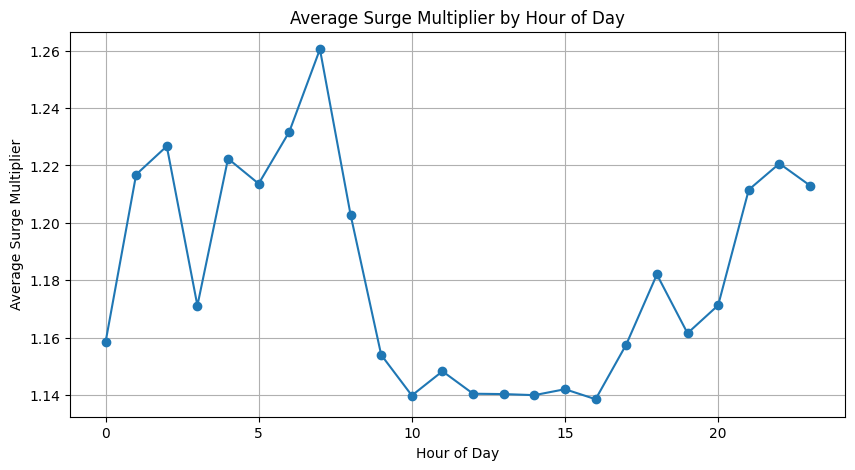

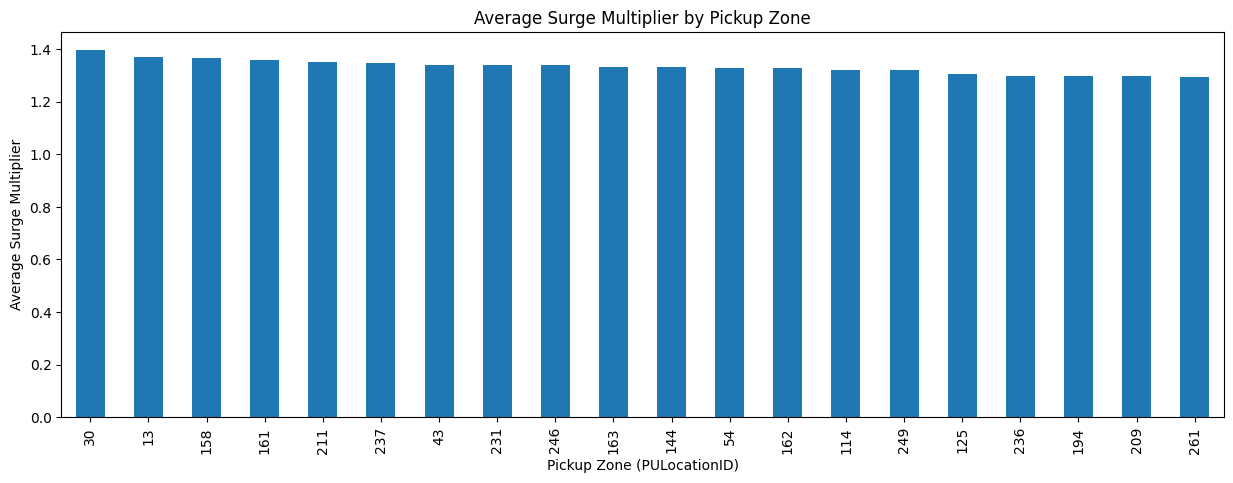

In [21]:
df_test = df_model_sample.iloc[split_index:].copy()
df_test['surge_multiplier'] = surge_multiplier
avg_surge_by_hour = df_test.groupby('hour')['surge_multiplier'].mean()
avg_surge_by_pu = df_test.groupby('PULocationID')['surge_multiplier'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.plot(avg_surge_by_hour.index, avg_surge_by_hour.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Surge Multiplier')
plt.title('Average Surge Multiplier by Hour of Day')
plt.grid(True)
plt.show()

plt.figure(figsize=(15,5))
avg_surge_by_pu.head(20).plot(kind='bar')
plt.xlabel('Pickup Zone (PULocationID)')
plt.ylabel('Average Surge Multiplier')
plt.title('Average Surge Multiplier by Pickup Zone')
plt.show()


## The average surge multiplier by hour and location both show logical trends
- ### The average surge multiplier by hour shows that off peak times (9PM-7AM) have a larger average surge multiplier than peak times (7AM-9PM)
- ### These pickup zones in NYC do not seem to have much variance in their average surge multiplier value

## LightGBM boost
- ### To begin exploring non-linear options, let's begin with LightGBM Regression
- ### LightGBM regression is a machine learning technique developed by Microsoft that splits data into multiple histograms (and hence multiple bins) through a second order Taylor expansion of the loss function 
- ### We would like to use LightGBM for the purposes of estimating the most impactful factors contributing to residuals in the relationship between predicted fare and actual fare

In [22]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, KFold
lgb_model = lgb.LGBMRegressor(objective = 'regression', random_state=42)
lgb_model.fit(X_train, y_train)
lgb_kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    estimator=lgb_model, 
    X=X, 
    y=y, 
    cv=lgb_kf, 
    scoring='neg_mean_squared_error',
    n_jobs=1
)
predictions = lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 982
[LightGBM] [Info] Number of data points in the train set: 750000, number of used features: 7
[LightGBM] [Info] Start training from score 26.209978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 7
[LightGBM] [Info] Start training from score 26.194936
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

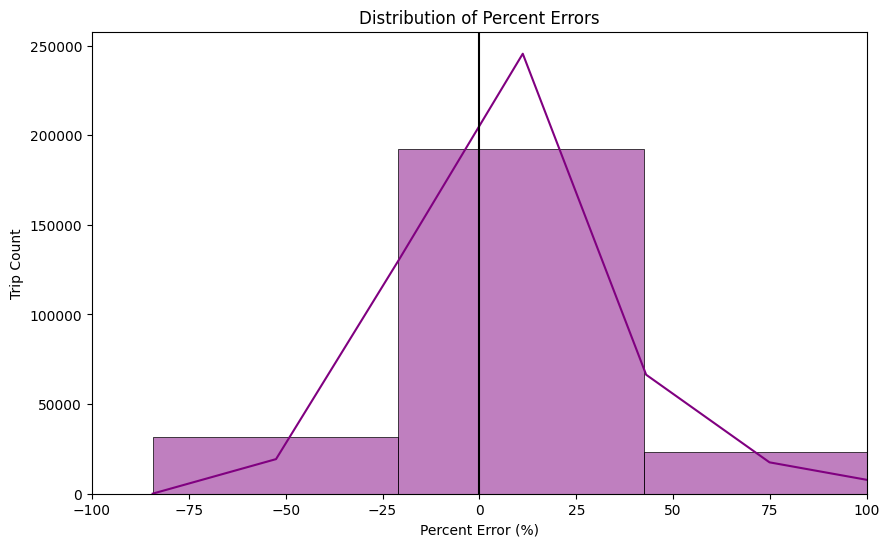

In [23]:
from scipy import stats
from sklearn.metrics import mean_absolute_percentage_error
rmse_scores = np.sqrt(-scores)

stats.describe(rmse_scores)

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

percent_errors = ((predictions - y_test) / y_test) * 100

plt.figure(figsize=(10, 6))
sns.histplot(percent_errors, bins=100, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='-')
plt.title('Distribution of Percent Errors')
plt.xlabel('Percent Error (%)')
plt.ylabel('Trip Count')
plt.xlim(-100, 100)
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

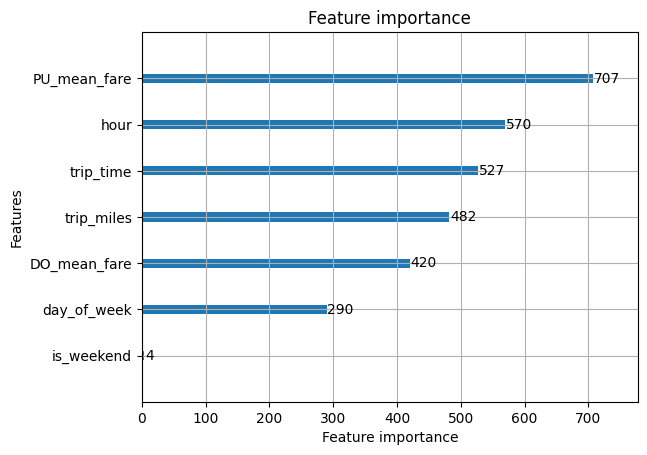

In [24]:
lgb.plot_importance(lgb_model)

## LightGBM Results
- ### LightGBM in this case provides us with a clear right skew in the data. What this means for us is that specific rideshares are showing to have some unexplained overpricing; a systemic bias by approximately 11% as shown by the mode of the KDE
- ### In essence, this model's most frequent prediction of consumer predicted fare is about 11% higher than the actual fare.
- ### We can also see, through the feature importance bar graph, that the pickup mean fare is the most significant driver of this 11% skew, followed by hour and trip time

## What This Most Likely Means
- ### This most likely means that rideshare companies are instilling a high dynamic pricing premium unto their customers. The reasons that customers are experiencing this dynamic pricing are based mostly on the fare at pickup, the hour of day, and the duration of the trip. Interestingly, and most notably, the day being a weekend rarely affects the dynamic pricing model. 

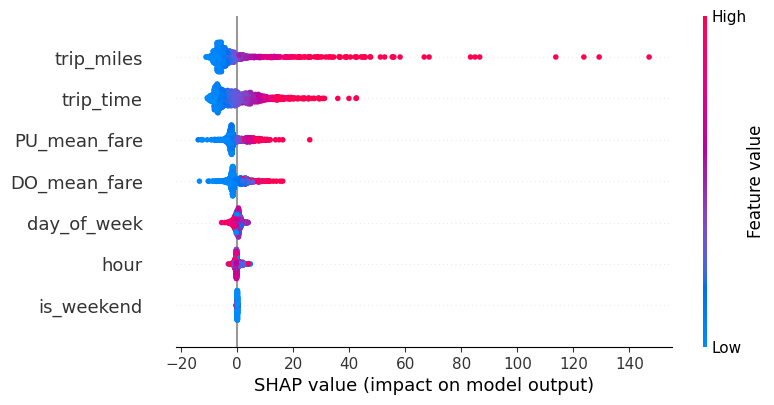

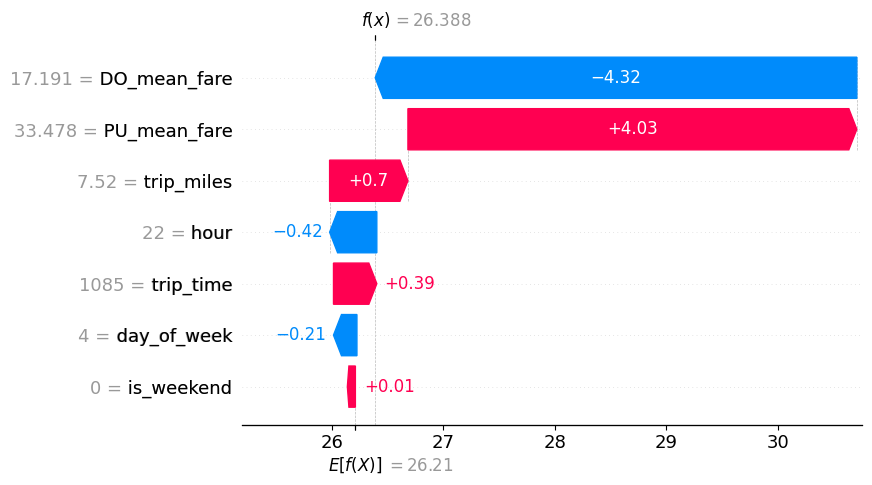

In [25]:
import shap
from sklearn.utils.validation import validate_data

explainer = shap.TreeExplainer(lgb_model)
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer(X_sample)
shap.plots.beeswarm(shap_values)
shap.plots.waterfall(shap_values[0])

## Beeswarm and Waterfall Plots

 ## **What are they**?
- ### Beeswarm and Waterfall plots, while both measures of significance of features of a model, describe the impact of variables on respective global and local scales

## How do they help?
- ### The beeswarm and waterfall plots above show a new perspective on the arguments made prior. The beeswarm plot states that the trip distance (in miles) is our most volatile feature and the waterfall plot states that, on a single chosen trip, the average dropoff fare actually saved more than the average pickup fare costed. 

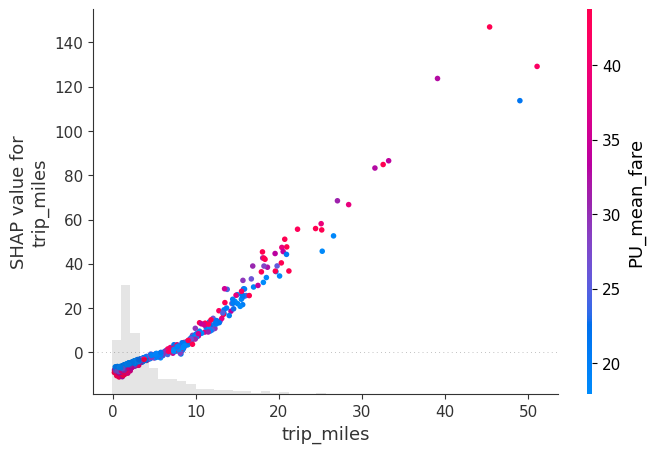

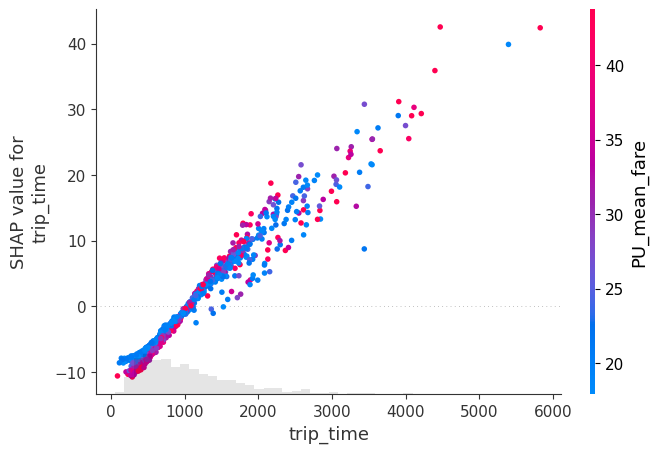

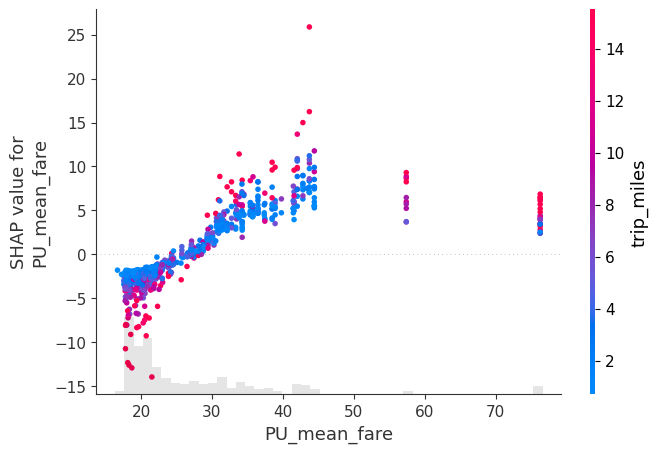

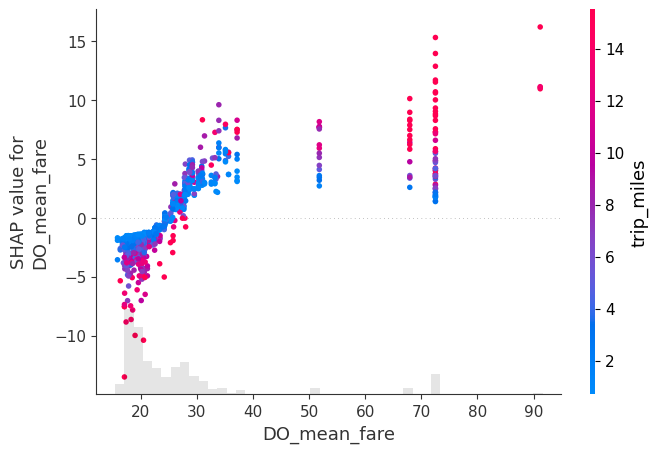

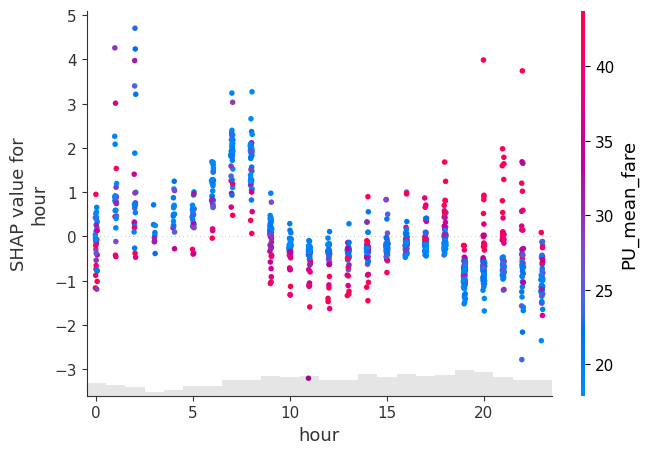

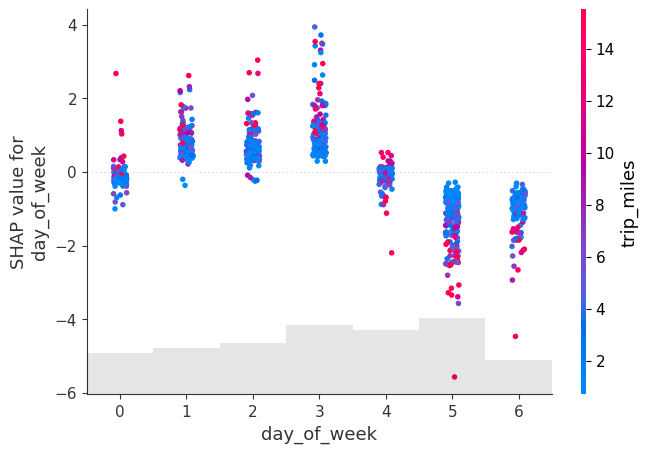

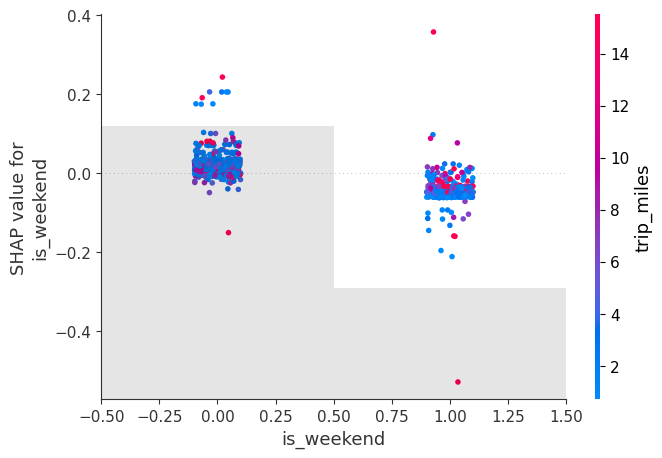

In [26]:
for feature in features:
    shap.plots.scatter(shap_values[:, feature], color=shap_values)
    plt.show()

## SHAP Graphs
- ### Distance and time are the biggest drivers of the model. The SHAP graphs show that the quantity of miles and overall fare have immeasurable impact on the prediction making of the model. Distance has an extreme impact with some SHAP values over 100 and time has a relatively smaller but still large impact with some values over 35
- ### The pickup and dropoff mean fare have some impact, but it is relatively small in comparison. These variables seem to have a similar impact in increasing the predictions of the model as they do in decreasing the predictions of the model
- ### The SHAP value ranges of hour, day_of_week and is_weekend are showing that these values have much less effect on the predictions of the model, but they do support a balanced amount of decreases and increases much like the pickup and dropoff mean fares

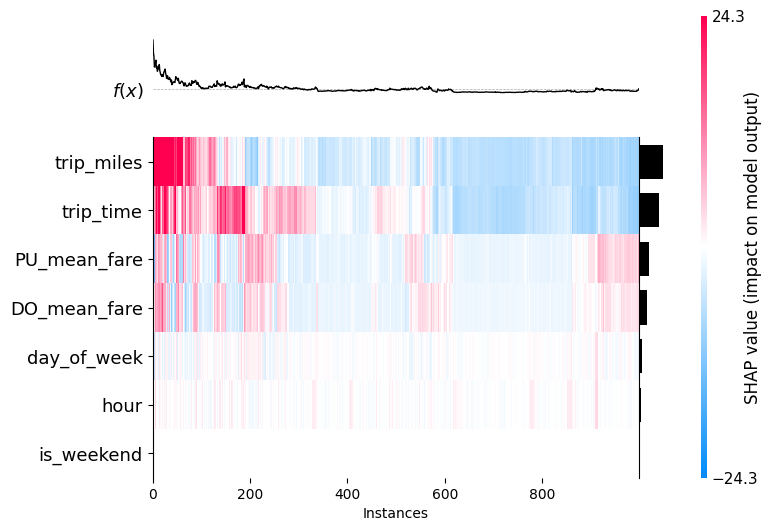

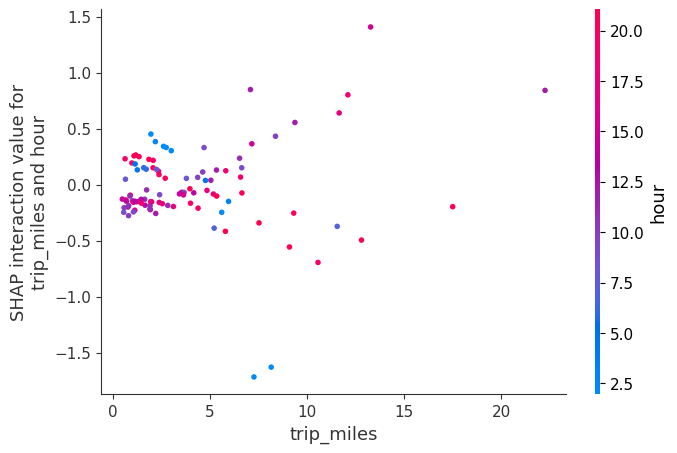

In [27]:
shap.plots.heatmap(shap_values)

explainer = shap.TreeExplainer(lgb_model)
X_sample = X_test.sample(100, random_state=42)
interaction_values = explainer.shap_interaction_values(X_sample)
shap.dependence_plot(
    ("trip_miles", "hour"),
    interaction_values, 
    X_sample
)


## What Impacts Price Volatility?
### The heatmap and dependence plot both support that the most dominant force in New York City rideshare price volatility is easily the distance that is traveled, followed by the amount of time that it takes to get to the destination
### The most consistent disproportionality seems to exist around the 20 mile and 2000 second (approximately half hour) distance and time range respectively

# Wrap up
 ## 1. Business and Consumer Implications
- ### Surge prices for rideshares in the New York City area are not caused by arbitrary inflation, but rather, by interaction effects. There is a compound effect that occurs when multiple variables all exceed a certain threshold, of which will increase the price of a trip exponentially.
- ### The variables that impact surge pricing the most are *the distance of the trip*, with exponential surges skyrocketing at about the 20 mile mark, and *the time of the trip*, with exponential surges skyrocketing at about the half hour mark.
- ### Further variables such as the average fare per pickup and dropoff location, the time of day, and day of the week or weekend have a comparably negligible impact on the price of trips in this area

## 2. What Could Happen Next: **Dynamic Margin Optimization**
- ### Now that our model understands not only the features that cause the most impact to surge price, but also is able to produce measurable quantities to describe that impact, rideshare companies can use this model to identify windows of opportunity to optimize margins
- ### *Pickup and Dropoff mean fare* margins can be optimized using GIS data, where driving to and from more affluent locations could provoke more of an exponential surge than other areas in the region
- ### **Hour* and *day of week* can be more readily optimized for workers who are more willing to tolerate spending more money due to a lack of alternative options to get to work

## 3. Consumer Sentiment & Long-term Risks
- ### While these optimizations represent significant profit opportunities, they carry a behavioral risk. Over-optimization of work commutes from specific GIS-mapped zones could eventually cause consumers to consider a lack of convenience over expensive pricing. If the compound effect of these variables makes the daily commute unpredictable, users may prioritize the fixed costs of public transit or private vehicle ownership, potentially eroding the long-term customer lifetime value.